# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
raw_df = pd.read_csv("tweet_sentiment_train.csv.zip")

In [3]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
raw_df.shape

(27481, 4)

Дані мають 27481 записів

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


Всі колонки є типу object. Є пропущєні дані в одному записі.

In [6]:
raw_df.dropna(inplace=True)

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [7]:
raw_df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


Розподіл міток класів:

40% нейтральні пости

31% позитивні

28% негативні

<Axes: xlabel='text', ylabel='Count'>

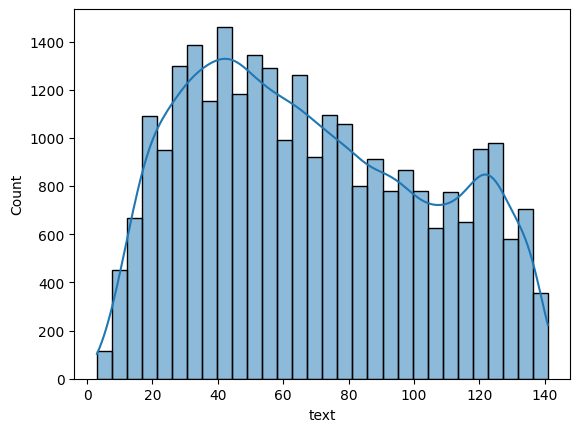

In [8]:
sns.histplot(raw_df['text'].str.len(), bins=30, kde=True)

Більше всього текстів довжиною 30-50 символів. Також є пік біля позначки 120 символв. Схоже, що люди схильні писати або короткі тексти, або досить великі.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




Перевіримо чи є в тексті посилання та не-алфавітні символи.

In [9]:
all_text = "".join(raw_df['text'].dropna().astype(str))
special_chars = set(re.findall(r'[^a-zA-Z\s]', all_text))

print("Знайдені спецсимволи та пунктуація:")
print(" ".join(sorted(special_chars)))

Знайдені спецсимволи та пунктуація:
! # $ % & ' ( ) * + , - . / 0 1 2 3 4 5 6 7 8 9 : ; < = > ? @ [ \ ] ^ _ ` { | } ~ ´ ½ ¿ Â ï


In [10]:
links_df = raw_df[raw_df['text'].str.contains('http', na=False)]
print(f"Кількість постів з посиланнями: {len(links_df)}")
print(links_df['text'].head())

Кількість постів з посиланнями: 1223
5     http://www.dothebouncy.com/smf - some shameles...
17    i`ve been sick for the past few days  and thus...
35    Thats it, its the end. Tears for Fears vs Eric...
50     Then you should check out http://twittersucks...
57        will be back later.  http://plurk.com/p/rp3k7
Name: text, dtype: object


Під час аналізу було виявлено, що символ * використовується для цензурування  (негативний контекст), та для виділення емоцій, як-от *huggles* чи *phew* (позитивний/нейтральний контекст). Через таку неоднозначність було прийнято рішення видалити зірочки як технічний шум, зберігаючи при цьому літери всередині них, щоб уніфікувати токени та зменшити розмір словника без втрати змісту.

In [11]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

In [13]:
def tokenize(text):
    return [stemmer.stem(word) for word in text.split() if word not in stop_words]

In [14]:
def preprocess_text(text):
    text = str(text).lower()
    # 2. Видалення посилань та спецсимволів
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 3. Токенізація та видалення стоп-слів + стеммінг
    tokens =  tokenize(text)

    return " ".join(tokens)

In [15]:
raw_df['clean_text'] = raw_df['text'].apply(preprocess_text)

In [16]:
raw_df.head()

,textID,text,selected_text,sentiment,clean_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,respond go
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,sooo sad miss san diego
2,088c60f138,my boss is bullying me...,bullying me,negative,boss bulli
3,9642c003ef,what interview! leave me alone,leave me alone,negative,interview leav alon
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,son put releas alreadi bought


In [18]:
all_words = " ".join(raw_df['clean_text']).split()

word_counts = Counter(all_words)
print(f"Загальна кількість унікальних слів: {len(word_counts)}")

frequent_words = [word for word, count in word_counts.items() if count > 5]
print(f"Кількість значущих слів (зустрічаються > 5 разів): {len(frequent_words)}")

Загальна кількість унікальних слів: 18628
Кількість значущих слів (зустрічаються > 5 разів): 3290


In [19]:
vectorizer = CountVectorizer(max_features=3000, min_df=5)
X = vectorizer.fit_transform(raw_df['clean_text'])

Аналіз показав, що в датасеті присутньо 3290 значущих слів (тих, що зустрічаються > 5 разів). Для побудови моделі було обрано max_features = 3000, щоб зосередитися на найбільш частотних токенах та уникнути перенавчання на рідкісних виразах.

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [20]:
indices = np.arange(X.shape[0])
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42)

X_train_bow = X[idx_train]
X_test_bow = X[idx_test]

y = raw_df['sentiment']
y_train = y.iloc[idx_train]
y_test = y.iloc[idx_test]

In [21]:
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train_bow, y_train)
log_reg_predictions = log_reg_model.predict(X_test_bow)

In [22]:
print(classification_report(y_test, log_reg_predictions))

              precision    recall  f1-score   support

    negative       0.69      0.60      0.64      1572
     neutral       0.64      0.72      0.68      2236
    positive       0.75      0.72      0.74      1688

    accuracy                           0.69      5496
   macro avg       0.69      0.68      0.68      5496
weighted avg       0.69      0.69      0.68      5496



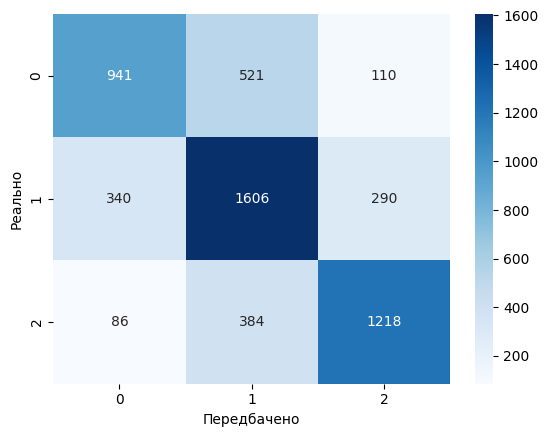

In [23]:
sns.heatmap(confusion_matrix(y_test, log_reg_predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Передбачено')
plt.ylabel('Реально')
plt.show()

Логістичная регресія дала macro f1 score 0.68 що є непоганим результатом. Також бачимо, що модель найкраще предебачає нейтральний клас, що є логічним результатом - оскільки нейтрального класу в нас більш за все в датасеті. Найскладніше модель передбачає негативний клас(521 раз неативний клас був розпізнан моделлю як нейтральний).

Натренуємо також LightGBM модель і порівняємо рузультати з Логістичною Регресією

In [24]:
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=500,     # кількість дерев
    learning_rate=0.05,    # крок навчання (чим менше, тим точніше, але довше)
    max_depth=6,           # глибина дерев, щоб не перенавчатися
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1)

X_train_bow = X_train_bow.astype('float64')
X_test_bow = X_test_bow.astype('float64')

lgbm.fit(X_train_bow, y_train)

y_pred_lgbm = lgbm.predict(X_test_bow)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [25]:
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

    negative       0.74      0.60      0.66      1572
     neutral       0.67      0.76      0.71      2236
    positive       0.76      0.76      0.76      1688

    accuracy                           0.71      5496
   macro avg       0.72      0.71      0.71      5496
weighted avg       0.72      0.71      0.71      5496



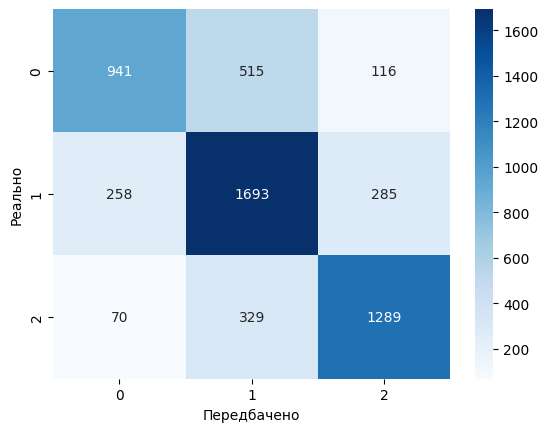

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Передбачено')
plt.ylabel('Реально')
plt.show()

На даний момент LightGBM э найкращою моделлю. Вона видає вищу загальну точність, краще розпізнає позитивні та нейтральні пости, але так само погано розпізнає негативні пости(515 негативних постів було розпізнано як нейтральні).

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [26]:
feature_names = vectorizer.get_feature_names_out()
importances = lgbm.feature_importances_
feature_importance_df = pd.DataFrame({
    'word': feature_names,
    'importance': importances
})
top_features = feature_importance_df.sort_values(by='importance', ascending=False).head(20)
top_features

,word,importance
1089,go,775
661,day,674
1068,get,426
1099,good,417
1564,love,356
1688,miss,283
1266,hope,264
1515,like,229
2931,work,213
943,feel,165


Аналіз впливовості ознак показав, що модель найбільше спирається на часто вживані слова (go, day, get) та яскраві емоційні маркери (good, love, miss, happi). На мій погляд, це логічно, оскільки позитивні слова (love, thank, good) зазвичай дуже однозначні, тому моделі легко використовувати їх для виділення класу positive. Нейтральні слова (work, time, day) допомагають ідентифікувати побутові повідомлення, яких у датасеті найбільше. Негативні слова (sad, sorri) мають високу важливість, але їх менше в топі, що пояснює, чому Recall негативного класу нижчий.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [32]:
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(raw_df['clean_text'])

In [33]:
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=500,     # кількість дерев
    learning_rate=0.05,    # крок навчання (чим менше, тим точніше, але довше)
    max_depth=6,           # глибина дерев, щоб не перенавчатися
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1)

X_train_bow = tfidf_matrix[idx_train].astype('float64')
X_test_bow = tfidf_matrix[idx_test].astype('float64')

lgbm.fit(X_train_bow, y_train)

y_pred_lgbm = lgbm.predict(X_test_bow)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [34]:
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

    negative       0.72      0.59      0.65      1572
     neutral       0.66      0.75      0.70      2236
    positive       0.77      0.75      0.76      1688

    accuracy                           0.70      5496
   macro avg       0.71      0.70      0.70      5496
weighted avg       0.71      0.70      0.70      5496



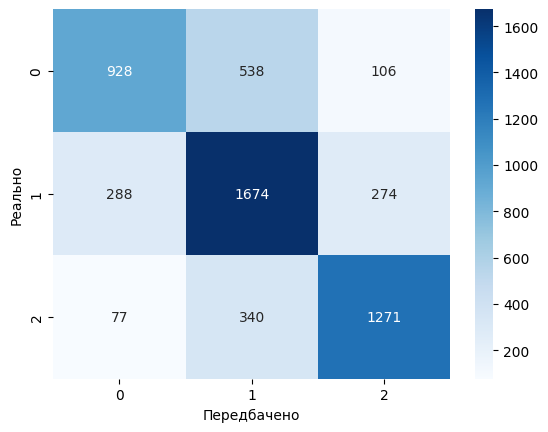

In [35]:
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Передбачено')
plt.ylabel('Реально')
plt.show()

Векторизація текстів з векторизатором TfidfVectorizer не призвела до поліпшення результатів класифікатора. F1 score знизився з 0.71 до 0.70. Модель стал трошки краще передбачати позитивний та нейтралний класи, але здатність передбачати негативний клас стала гіршою порівняно з тим що вдалось досягти с векторизатором CountVectorizer.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [37]:
results_df = pd.DataFrame({
    'text': raw_df.loc[idx_test, 'text'].values,
    'clean_text': raw_df.loc[idx_test, 'clean_text'].values,
    'actual': y_test,
    'predicted': y_pred_lgbm
})

errors = results_df[results_df['actual'] != results_df['predicted']]

print(f"Загальна кількість помилок: {len(errors)}")
display(errors.sample(10))

Загальна кількість помилок: 1623


,text,clean_text,actual,predicted
8137,I always feel sickly when I wake up. Well got...,alway feel sick wake well got busi day ahead y...,negative,neutral
10250,gonna go home and TRY to take a nap. I am emo...,gonna go home tri take nap emot exhaust,neutral,positive
24840,..i`m a buffalo worshipper ... maybe it is t...,buffalo worshipp mayb time pay visit prefer bu...,negative,neutral
24393,Iï¿½m JBobsessed xD I miss them soooooo much!...,jbobsess xd miss soooooo much live web cast bo...,positive,neutral
17078,happy early mothers day!!!!,happi earli mother day,neutral,positive
21119,Monday mornings couldn`t exist if it weren`t f...,monday morn exist hot tea,positive,neutral
7396,Why the **** can`t I be over this ??? I feel l...,feel like cri bit reali want bother sooooooo much,neutral,negative
27140,Mount dishes have been conquered. Dish land is...,mount dish conquer dish land,neutral,positive
5688,thinking of you why we canï¿½t control our t...,think control thought,negative,neutral
12759,oooh im sorry to late i smashed it,oooh im sorri late smash,positive,negative


In [38]:
negative_errors = errors[errors['actual'] == 'negative']
print(f"Кількість помилок у негативних твітах: {len(negative_errors)}")

display(negative_errors.head(15))

Кількість помилок у негативних твітах: 644


,text,clean_text,actual,predicted
10414,Sorry but there is no parking space. And I ju...,sorri park space realiz delet one sentenc copi...,negative,neutral
6718,looking for new ideas for my blog,look new idea blog,negative,neutral
2831,I think they make you turn your phones off I...,think make turn phone see,negative,positive
16793,Ugh - car got stolen sometime between yesterda...,ugh car got stolen sometim yesterday even morn...,negative,neutral
12312,I`ve been using the Sennheiser CX 300 earbuds...,use sennheis cx earbud month love know avail m...,negative,neutral
15661,i widddd but i`ll be on a bus to london & ...,widddd bus london also,negative,neutral
24797,going out on thursdays is a terrible idea. i k...,go thursday terribl idea knew reason done quar...,negative,neutral
20028,Thinks he may have broken his nose at the show,think may broken nose show,negative,neutral
23914,aww lovely! Hope you had a great mother`s day...,aww love hope great mother day littl mother he...,negative,neutral
853,"lol, i`ve done that one b4 i`m a victim 2 th...",lol done one b victim lol,negative,neutral


Детальний аналіз помилок на негативних прикладах дозволив виділити три основні причини слабкого передбачення негативного класу:

* Переважання позитивних токенів у негативних фразах: класифікатор надає велику вагу словам love, hope, great, через що саркастичні або ввічливі негативні твіти визначаються як нейтральні або позитивні.

* Брак явних емоційних маркерів.

* Шум у даних: частина помилок спричинена неоднозначністю самого датасету, де нейтральні за змістом фрази мають мітку negative.

**Шляхи поліпшення якості класифікатора**

* Через те що дані не збаласовані і негатисного класу всього 28%, а нейтральних аж 40% модель погано навчилась передбачати негативний клас та більш тяжіє до нейтрального. Варто спробувати використати метод Undersampling (вирівняти кількість нейтральних постів до кількості негативних,  видаливши частину нейтральних перед навчанням).

* Замінити стемінг на лематизацію. Аналіз найвпливовіших слів показав, що стеммінг створює штучні токени (happi, sorri). Перехід до лематизації дозволить зберегти словникову форму слів та краще об'єднати різні граматичні форми дієслів та прикметників.

* Обробка емодзі та емотиконів.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model